## Memory Store Integrating with the LangGraph

### Step 1 : Reading the existing Memory


#### before answering the llm seek the memorystore and personalize the response, just look into the existing memory

In [1]:
# first create the memory store pre built
from langgraph.store.memory import InMemoryStore
store = InMemoryStore()
user_details = ('user','raju','details')
store.put(user_details,'name',{'data':'user name is raju joshi'})
store.put(user_details,'language',{'data':'user likes python over any other language'})
store.put(user_details,'country',{'data':'user is from nepal'})
store.put(user_details,'hobbies',{'data':'user has a hobby of playing cricket video creation and flute playing'})
store.put(user_details,'education',{'data':'user is a graduate cse student'})
store.put(user_details,'working',{'data':'user is an agentic ai engineer at albaconnect'})

In [2]:
# create a prompt
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import SystemMessage

prompt = PromptTemplate(
        template= """You are a helpful assistant with memory capabilities.
                If user-specific memory is available, use it to personalize 
                your responses based on what you know about the user.

                Your goal is to provide relevant, friendly, and tailored 
                assistance that reflects the user’s preferences, context, and past interactions.

                If the user’s name or relevant personal context is available, always personalize your responses by:
                    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
                    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
                    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

                Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
                say "Since your project is built with TypeScript..."

                Use personalization especially in:
                    – Greetings and transitions
                    – Help or guidance tailored to tools and frameworks the user uses
                    – Follow-up messages that continue from past context

                Always ensure that personalization is based only on known user details and not assumed.

                In the end suggest 3 relevant further questions based on the current response and user profile

                The user’s memory (which may be empty) is provided as: {user_details_content}
            """,
        input_variables=['user_details_content']

)

In [5]:
# build the graph start -> chat-> end
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
llm = ChatOpenAI(model = 'gpt-4o-mini')

In [6]:
from langgraph.graph import StateGraph,START,END,MessagesState


In [7]:
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import BaseStore

In [12]:
def chat_node(state: MessagesState,config : RunnableConfig,store : BaseStore):
    user_id = config['configurable']['thread_id']
    user_details = ('user',user_id,'details')

    items = store.search(user_details)

    if items :
        user_detailed_content = '\n'.join(it.value.get('data','') for it in items)
    else:
        user_detailed_content = ''

    prompt_value = prompt.invoke(input = {
        'user_details_content':user_detailed_content
    })
    system_prompt = SystemMessage(content = prompt_value.to_string())

    response = llm.invoke([system_prompt]+state['messages']) # injecting the ltm into the context window as a part of stm
    return {'messages':[response]}



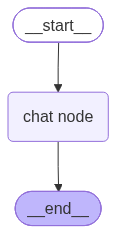

In [13]:
builder = StateGraph(state_schema=MessagesState)
builder.add_node('chat node',chat_node)
builder.add_edge(START,'chat node')
builder.add_edge('chat node',END)
graph = builder.compile(store = InMemoryStore())
graph

In [10]:
from langchain_core.messages import HumanMessage

In [14]:
# now run the graph with config
config1 = {'configurable':{'thread_id':'session-1'}}
result = graph.invoke({
    'messages':[HumanMessage(content= 'explain gen ai in the simpler terms')]
},config=config1)
result

{'messages': [HumanMessage(content='explain gen ai in the simpler terms', additional_kwargs={}, response_metadata={}, id='af295584-59b5-4af7-bc88-78c131079106'),
  AIMessage(content="Sure, Gen AI, or Generative Artificial Intelligence, refers to AI systems that can create new content, such as text, images, music, or even video. Instead of just analyzing or processing existing content, generative AI learns patterns from a large amount of data and then uses this knowledge to generate original pieces of creative work.\n\nFor example, if you give a generative AI model a prompt or some initial information, it can produce a new story, a unique piece of art, or a song that didn't exist before. It’s like having a very intelligent assistant that can create new things based on what it has learned!\n\nIf you're curious about how this type of AI could relate to your work or interests, feel free to ask!\n\nHere are some questions you might consider:\n1. Are you interested in how generative AI can b

In [15]:
print(result['messages'][-1].content)

Sure, Gen AI, or Generative Artificial Intelligence, refers to AI systems that can create new content, such as text, images, music, or even video. Instead of just analyzing or processing existing content, generative AI learns patterns from a large amount of data and then uses this knowledge to generate original pieces of creative work.

For example, if you give a generative AI model a prompt or some initial information, it can produce a new story, a unique piece of art, or a song that didn't exist before. It’s like having a very intelligent assistant that can create new things based on what it has learned!

If you're curious about how this type of AI could relate to your work or interests, feel free to ask!

Here are some questions you might consider:
1. Are you interested in how generative AI can be applied in specific fields, like art or writing?
2. Do you want to know about any popular tools or platforms that use generative AI?
3. Would you like examples of generative AI in action o

## Step 2 : Concept of Creating new memory while chatting

##### till now we know how to interact with the created memory but creating long term memory is the actual big deal here we know how to create the long term memory so firstly we just solo create a long term memory. we learn how to create the long term memory.